In [ ]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re

from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler 
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    ##  K-means 임포트
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

plt.rc('font',family='D2CodingLigature Nerd Font')
# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시

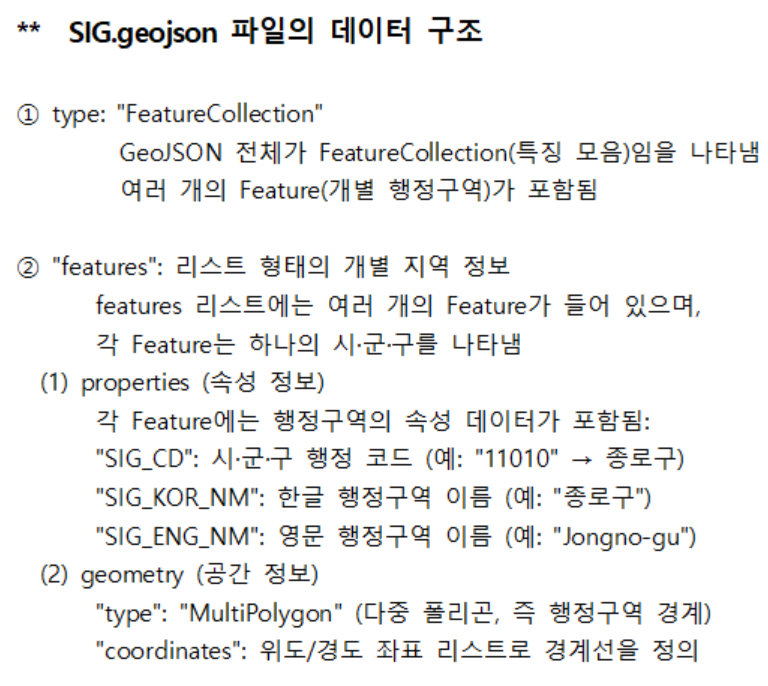

In [ ]:
import json
geo = json.load(open('../../data/SIG.geojson', encoding = 'UTF-8')) 

In [ ]:
# 행정 구역 코드 출력 
geo['features'][0]['properties']

In [ ]:
# 행정 구역 코드 출력 
geo['features'][0]['geometry']

### 시군구별 인구데이터 준비하기

In [ ]:
## Population_SIG.csv: 지도에 표현할 시군구별 인구 통계 데이터
## 2021년의 시군구별 행정 구역 코드, 지역 이름, 인구를 담고 있음

df_pop = pd.read_csv('../../data/Population_SIG.csv')
df_pop.head()

In [ ]:
df_pop.info()

In [ ]:
# code 항목을 문자 타입으로 바꾸기
df_pop['code'] = df_pop['code'].astype(str)

In [ ]:
df_pop.info()

### 배경 지도 만들기

In [ ]:
map_sig1 = folium.Map(location = [35.95, 127.7],  zoom_start = 8, tiles = 'cartodbpositron') 
# map_sig1 = folium.Map(location = [35.95, 127.7],  zoom_start = 8, tiles = 'OpenStreetMap')
map_sig1

## tiles 옵션 ==> "OpenStreetMap", "Stamen Terrain", "Stamen Toner" 등

In [ ]:
folium.Choropleth(geo_data = geo,
                  data = df_pop,
                  columns = ('code', 'pop'),
                  key_on = 'feature.properties.SIG_CD',
                  fill_color='YlGnBu',
                  bins = list(df_pop['pop'].quantile([0, 0.2, 0.4, 0.6, 0.8, 1])),
                  fill_opacity=1,
                  line_opacity=0.2,
                  legend_name='시군구별 인구 수') \
      .add_to(map_sig1)

map_sig1

### 행정구역 이름과 인구수 표시

In [ ]:
# GeoJSON의 'features' 부분에 인구 정보 추가
for feature in geo['features']:
    sig_cd = feature['properties']['SIG_CD']  # GeoJSON의 시군구 코드
    pop_data = df_pop[df_pop['code'] == sig_cd]  # 해당 코드의 인구 데이터 찾기
    
    if not pop_data.empty:  ## 인구 데이터가 존재할 경우만
        # 인구 수를 GeoJSON의 속성에 추가, int64를 int로 변환
        feature['properties']['pop'] = int(pop_data['pop'].values[0])

In [ ]:
# 새로운 배경 지도 만들기
map_sig2 = folium.Map(location=[35.95, 127.7], zoom_start=8, tiles='cartodbpositron')

# Choropleth 추가
folium.Choropleth(geo_data=geo,  # 시군구 경계 GeoJSON 파일
    data=df_pop,  
    columns=('code', 'pop'),  
    key_on='feature.properties.SIG_CD',  
    fill_color='YlGnBu',  
    bins = np.quantile(df_pop['pop'], np.linspace(0, 1, 6)), 
    fill_opacity=0.8,
    line_opacity=0.2,
    # line_weight=0.1,  # 경계선 굵기 조절 (기본값은 1)
    legend_name="서울시 인구"  
).add_to(map_sig2)

# 툴팁 추가: 각 군구에 마우스를 올리면 인구 수와 군구 코드 표시
folium.GeoJson(
    geo,
    tooltip=folium.GeoJsonTooltip(
        fields=['SIG_KOR_NM', 'pop'],  # 표시할 필드 (코드와 인구)
        aliases=['군구', '인구 수'],  # 필드에 대한 별칭
        localize=True,  # 숫자 포맷 설정 (지역화)
        sticky=True  # 툴팁이 마우스가 올려진 상태에서 지속적으로 표시되도록
    )
).add_to(map_sig2)

map_sig2